# Regularization with Combinations of dq and q
This notebook shows how to use both the L2 norm of q and the L2 norm of its first difference dq for regularization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize

In [2]:
def load_fr(fr_path, scale=0.1, tail=0):
    """
    Load response kernel `fr` similar to your org-file.
    If 3D, uses fr[0, 0, -tail:] * scale.
    If 1D, uses the last `tail` samples (or full length if shorter) and scales.
    """
    if tail != 0:
        raise ValueError
    arr = np.load(fr_path)
    if arr.ndim == 3:
        fr_raw = arr[0, 0, ]
    # elif arr.ndim == 1:
    #     fr_raw = arr[-min(tail, arr.shape[0]):]
    else:
        # Fallback: flatten last axis if needed
        fr_raw = np.ravel(arr)[-min(tail, arr.size):]
    fr = fr_raw.astype(np.float64) * scale
    return fr

In [3]:
def build_frm(fr, N, T=None):
    """
    Toeplitz convolution matrix frm of shape (T, N),
    where T = len(fr) + N - 1.
    """
    if T is None:
        T = len(fr) + N - 1
    c = np.r_[fr, np.zeros(T-len(fr), dtype=np.float64)]
    r = np.r_[fr[0], np.zeros(T-len(fr)-1, dtype=np.float64)]
    frm = scipy.linalg.toeplitz(c, r)   # (T, N)
    return frm

In [4]:
def build_Ae_from_pt(hts_pt0, hts_pt1, T, reset_time=2, end_exclusive=True):
    """
    Build integration/aggregation matrix Ae of shape (M, T),
    marking ones across [pt0, pt1) if end_exclusive else [pt0, pt1+1).
    """
    M = len(hts_pt0) + 1
    Ae = np.zeros((M, T), dtype=np.float64)
    assert hts_pt0[0] >= 0
    Ae[0, 0:hts_pt0[0]] = 1.0  # pre-window zeros
    Ae[1, hts_pt0[0]:hts_pt1[0]] = 1.0  # pre-window zeros
    if end_exclusive:
        for i in range(1, M-1):
            s = int(hts_pt1[i-1]+reset_time)
            e = int(hts_pt1[i])
            s = max(s, 0)
            e = min(e, T)
            assert e < T
            if e > s:
                Ae[i+1, s:e] = 1.0
    else:
        for i in range(1, M):
            s = int(hts_pt1[i-1]+reset_time)
            e = int(hts_pt1[i]) + 1  # inclusive end -> make exclusive
            s = max(s, 0)
            e = min(e, T)
            assert e < T
            if e > s:
                Ae[i+1, s:e] = 1.0
    return Ae

In [5]:
def make_diff(N, order=1):
    """
    Finite difference matrix of shape (N-order, N).
    """
    if order < 1:
        raise ValueError("order must be >= 1")
    I = np.eye(N, dtype=np.float64)
    D = I[1:] - I[:-1]
    for _ in range(1, order):
        D = D[1:] - D[:-1]
    return D

In [6]:
def solve_tikhonov_combo(A, y, lam_q=0.0, lam_dq=0.0):
    """
    Solve min ||A q - y||_2^2 + lam_q ||q||_2^2 + lam_dq ||D q||_2^2
    Returns q_hat and residual norm.
    """
    A = np.asarray(A, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    M, N = A.shape
    aug_rows = []
    aug_targets = []
    if lam_q > 0.0:
        aug_rows.append(np.sqrt(lam_q) * np.eye(N))
        aug_targets.append(np.zeros(N))
    if lam_dq > 0.0:
        D = make_diff(N, order=1)
        aug_rows.append(np.sqrt(lam_dq) * D)
        aug_targets.append(np.zeros(N-1))
    if aug_rows:
        A_aug = np.vstack([A] + aug_rows)
        y_aug = np.concatenate([y] + aug_targets)
    else:
        A_aug = A
        y_aug = y
    q_hat, *_ = scipy.optimize.nnls(A_aug, y_aug)
    resid = np.linalg.norm(A @ q_hat - y)
    return q_hat, resid

In [11]:
def solve_one_group(fr, hqs_group, pt0_group, pt1_group, spacing, lam_q=0.0, lam_dq=0.0, pre_n=1, post_n=1, end_exclusive=True):
    """
    Build Ae and frm for a group, solve for q_hat, and (optionally) block x_hat.
    Returns a dict with results and a small summary.
    """
    # Determine total length T from pt1. Assume pt1 is an exclusive end by default.
    # post_n = 1  # assume 1 extra spacing after last hit if signal is too small to detect; signal is assumed to be no earlier than first hit.
    # pre_n = 1 # assume 1 extra spacing before first hit, which is from suppression of induction

    # truncate time to index

    # FIXME: how to deal with negative?
    start_idx = ((np.min(pt0_group) - 10.431 / 0.16 // 0.05) // spacing - pre_n) * spacing
    end_idx = ((np.max(pt1_group) - 10.431 / 0.16 // 0.05) // spacing + post_n) * spacing
    start_idx = int(start_idx)
    end_idx = int(end_idx)
    N = end_idx - start_idx
    K = N // spacing
    # print(N, start_idx, end_idx)
    # print("range of indices", start_idx, end_idx, max_end)
    # Proj = np.eye(N,) - proj @ proj.T
    mask = np.ones((N,), dtype=float)
    Proj = np.diag(1.0 - mask)
    pt0_group = pt0_group - start_idx
    pt1_group = pt1_group - start_idx
    T = N + len(fr)
    Ae  = build_Ae_from_pt(pt0_group, pt1_group, T, reset_time=2, end_exclusive=end_exclusive)  # (M, T)
    frm = build_frm(fr, N, T)                             # (T, N)
    A   = Ae @ frm                                     # (M, N)
    y = np.zeros((len(hqs_group)+1,), dtype=np.float64)
    y[1:] = hqs_group

    thres = 5
    y[0] = thres  # enforce some minimum signal before first hit
    y[1] = y[1] - thres

    # print("A.shape", A.shape, "frm.shape", frm.shape, "Ae.shape", Ae.shape, y.shape)

    # Solve for q
    q_hat, resid = solve_tikhonov_combo(A, y, lam_q=lam_q, lam_dq=lam_dq)


    result = {
        "ok": True,
        "start_idx": start_idx,
        "T": T,
        "N": N,
        "M": A.shape[0],
        # "residual_norm": float(resid),
        "q_hat": q_hat,          # length N
        "A" : A,
        "Ae" : Ae,
        "frm" : frm,
    }

    return result



In [8]:
def condense_effq_by_pxpy(effq, effq_loc, spacing=50, px_col=0, py_col=1, t_col=2, drop_zero_bins=True):
    """
    Group by (px, py), bin time t into [k*spacing, (k+1)*spacing) bins,
    and sum effq weights inside each bin.

    Returns:
      dict keyed by (px, py) -> {
          "bin_left": 1D array of left edges,
          "bin_right": 1D array of right edges,
          "sum": 1D array of accumulated effq per bin,
          "bin_index": 1D array of integer bin indices (for reference)
      }
    """
    effq = np.asarray(effq, dtype=float).reshape(-1)
    effq_loc = np.asarray(effq_loc)

    if effq_loc.ndim != 2 or effq_loc.shape[1] <= max(px_col, py_col, t_col):
        raise ValueError("effq_loc must be a 2D array with at least three columns [px, py, t].")

    if len(effq) != len(effq_loc):
        raise ValueError("effq and effq_loc must have the same length.")

    px = effq_loc[:, px_col]
    py = effq_loc[:, py_col]
    t  = effq_loc[:, t_col]

    # Bin index: k = floor(t / spacing), clamp negatives to 0
    bin_idx_all = np.floor(t / spacing).astype(int)
    bin_idx_all[bin_idx_all < 0] = 0

    # Unique groups by (px, py)
    pairs = np.stack([px, py], axis=1)
    uniq_pairs, inv = np.unique(pairs, axis=0, return_inverse=True)

    result = {}
    for gi, (px_val, py_val) in enumerate(uniq_pairs):
        sel = (inv == gi)
        if not np.any(sel):
            continue

        bins_g = bin_idx_all[sel]
        effq_g = effq[sel]

        nbins = int(np.max(bins_g)) + 1  # cover [0, ..., max_bin]
        sums = np.bincount(bins_g, weights=effq_g, minlength=nbins)

        # Build edges for readability
        bin_left = np.arange(nbins) * spacing
        bin_right = bin_left + spacing

        if drop_zero_bins:
            nz = sums != 0
            bin_left = bin_left[nz]
            bin_right = bin_right[nz]
            sums = sums[nz]
            bins_out = np.arange(nbins)[nz]
        else:
            bins_out = np.arange(nbins)

        result[(px_val, py_val)] = {
            "bin_left": bin_left,
            "bin_right": bin_right,
            "sum": sums,
            "bin_index": bins_out
        }

    return result

In [12]:
def study_lam_combo(lam_q, lam_dq, pre_n=1, post_n=1, spacing=50):
    tail = 0
    fnpz = "single_track_for_sp.npz"
    file_fr = "single_unipolar_response.npy"
    frscale = 0.05
    spacing = 50  # 0.05 ns * 0.16 cm/us * 50 = 0.04 cm
    end_exclusive = True # Treat pt1 as exclusive end (default).
    thres = 5
    # Correction offset for t
    t_offset = -10.431 / 0.16 // 0.05
    diff_hist = []
    # Load data
    npz = np.load(fnpz)
    hqs_all = np.asarray(npz["hits_tpc0_batch10"][:,-1], dtype=np.float64).reshape(-1)
    locs    = np.asarray(npz["hits_tpc0_batch10_location"])
    if locs.ndim != 2:
        raise ValueError("hits_tpc0_batch10_location must be a 2D array.")
    # Column extraction
    px_all  = locs[:, 0]
    py_all  = locs[:, 1]
    pt0_all = locs[:, 2]
    pt1_all = locs[:, 3]
    # Sanity: lengths must match
    if not (len(hqs_all) == len(px_all) == len(py_all) == len(pt0_all) == len(pt1_all)):
        raise ValueError("Mismatched lengths across hqs and location columns.")
    # Load kernel
    fr = load_fr(file_fr, scale=frscale, tail=tail)
    assert len(fr) % 50 == 0, "length of fr must be dividable by 50 for spacing=50"
    # Group by (px, py)
    pairs = np.stack([px_all, py_all], axis=1)
    uniq_pairs, inverse_idx = np.unique(pairs, axis=0, return_inverse=True)
    print(f"Loaded: {len(hqs_all)} hits; unique (px, py) groups = {len(uniq_pairs)}")
    print(f"Kernel: len(fr)={len(fr)}, sum(fr)={np.sum(fr):.6g}")
    effq = npz["effq_tpc0_batch10"][:,-1]
    effq_loc = npz["effq_tpc0_batch10_location"]  # columns: [px, py, t]
    condensed = condense_effq_by_pxpy(effq, effq_loc, spacing=spacing)
    hit_pair = {}
    pixel_pair = {}
    # Solve per group
    for gi, (px_val, py_val) in enumerate(uniq_pairs):
        sel = (inverse_idx == gi)
        hqs_g  = hqs_all[sel]
        pt0_g  = pt0_all[sel]
        pt1_g  = pt1_all[sel]
        res = solve_one_group(fr, hqs_g, pt0_g, pt1_g, spacing=spacing, lam_q=lam_q, lam_dq=lam_dq, end_exclusive=end_exclusive)
        header = f"(px={px_val}, py={py_val})  |  M={len(hqs_g)}"
        if not res["ok"]:
            print(f"  SKIP: {res['reason']}")
            print("-" * 80)
            continue
        N = res["N"]
        start_idx = res["start_idx"]
        q_hat = res["q_hat"]
        q_bins_t = np.arange(N) + start_idx
        effq_info = condensed.get((px_val, py_val), None)
        effq_bins_t = effq_info["bin_left"] + t_offset if effq_info is not None else np.array([])
        effq_vals = effq_info["sum"] if effq_info is not None else np.array([])
        # For each q_hat bin, find effq bin (if any) and compute difference

        # condense q_hat into spacing bins
        q_hat_binned = np.add.reduceat(q_hat, np.arange(0, len(q_hat), spacing))
        q_hat_binned_t = np.arange(len(q_hat_binned)) * spacing + start_idx
        for i, t_bin in enumerate(effq_bins_t):
            # Find q_hat bin index
            idx = np.where(q_bins_t == t_bin)[0] if effq_info is not None else []
            if len(idx) > 0:
                diff = q_hat_binned[idx[0] // spacing] - effq_vals[i]
            else:
                diff = -effq_vals[i]
            diff_hist.append(diff)
        for i, t_bin in enumerate(q_hat_binned_t):
            idx = np.where(effq_bins_t == t_bin)[0] if effq_info is not None else []
            if len(idx) > 0:
                continue  # already counted in previous loop
            else:
                diff = q_hat_binned[i]
            diff_hist.append(diff)
        pixel_pair[(px_val, py_val)] = (0, np.sum(q_hat),
                                        np.sum(effq_info["sum"]) if effq_info is not None else 0,
                                        np.sum(hqs_g))
    for k in condensed.keys():
        if k in pixel_pair.keys():
            continue
        pixel_pair[k] = (0, 0, np.sum(condensed[k]['sum']), 0)
    diff_hist = np.array(diff_hist, dtype=np.float64)
    # Plot histogram of differences
    plt.figure(figsize=(8,5))
    plt.hist(diff_hist, bins=40, alpha=0.7)
    plt.xlabel("q_hat - effq (per pixel, per t bin)")
    plt.ylabel("Count")
    plt.title("Histogram of q_hat - effq differences; lamq=%.1e, lamdq=%.1e" % (lam_q, lam_dq))
    plt.show()
    # ...existing summary plot...
    q_hat_vals = [p[1] for p in pixel_pair.values()]
    effq_vals = [p[2] for p in pixel_pair.values()]
    plt.figure(figsize=(10,6))
    plt.plot(effq_vals, q_hat_vals, 'o')
    plt.plot(np.arange(0, 30, 0.1), np.arange(0, 30, 0.1), '--')
    plt.xlabel("effq per pixel")
    plt.ylabel("q_hat per pixel")
    plt.title("Total q_hat vs effq per pixel; lamq=%.1e, lamdq=%.1e" % (lam_q, lam_dq))
    plt.show()

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


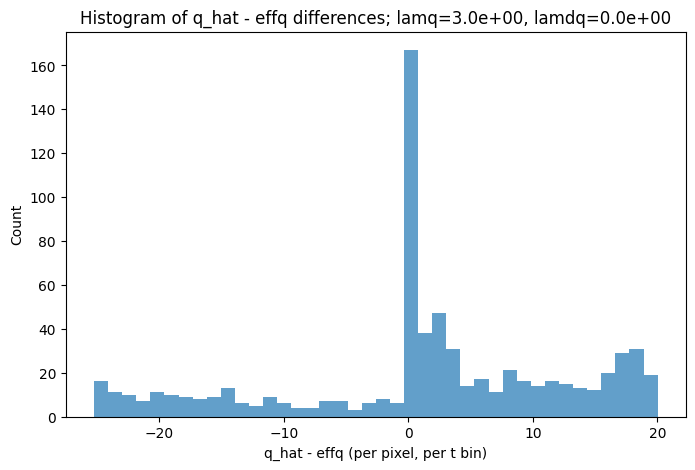

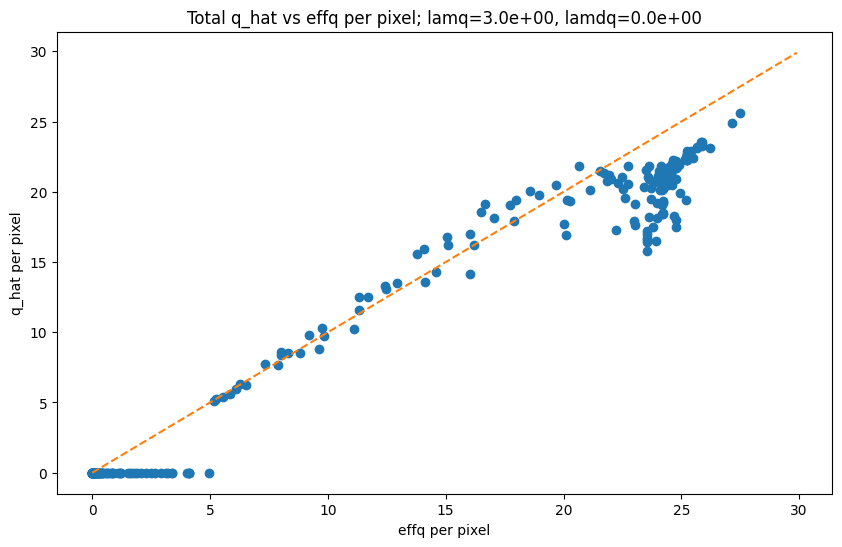

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


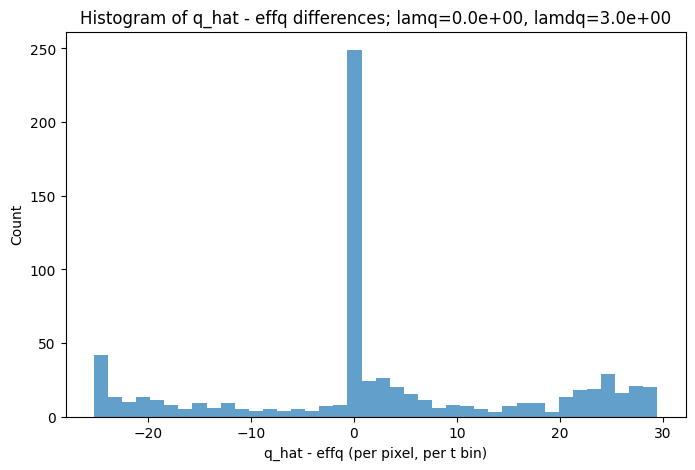

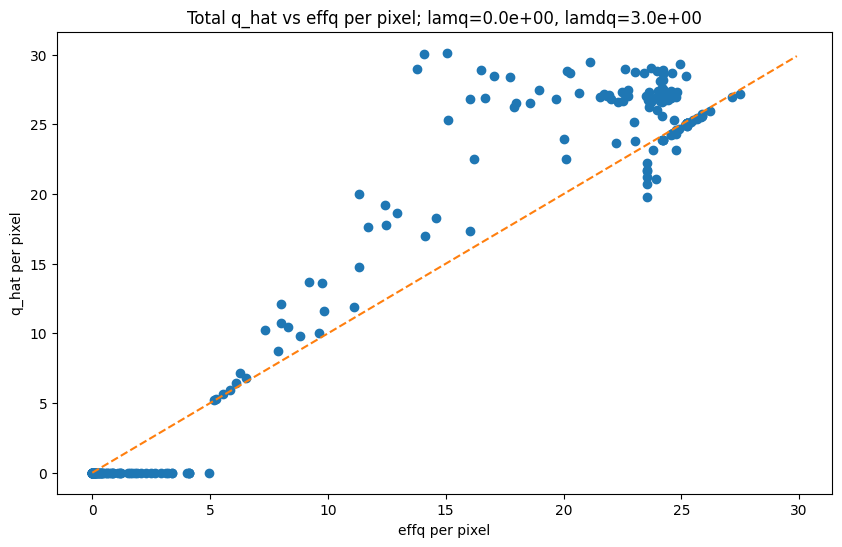

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


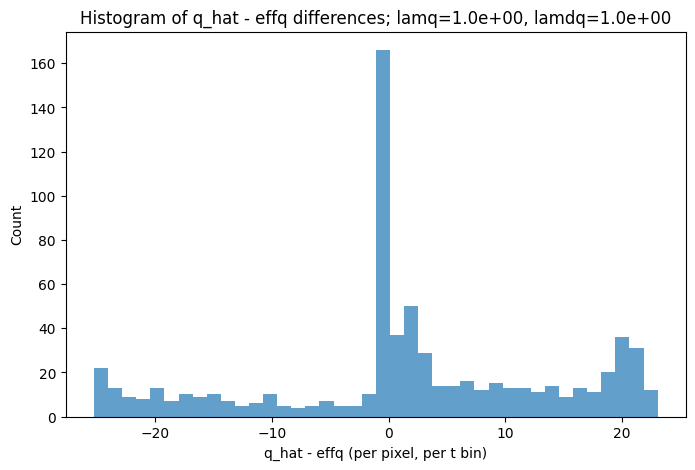

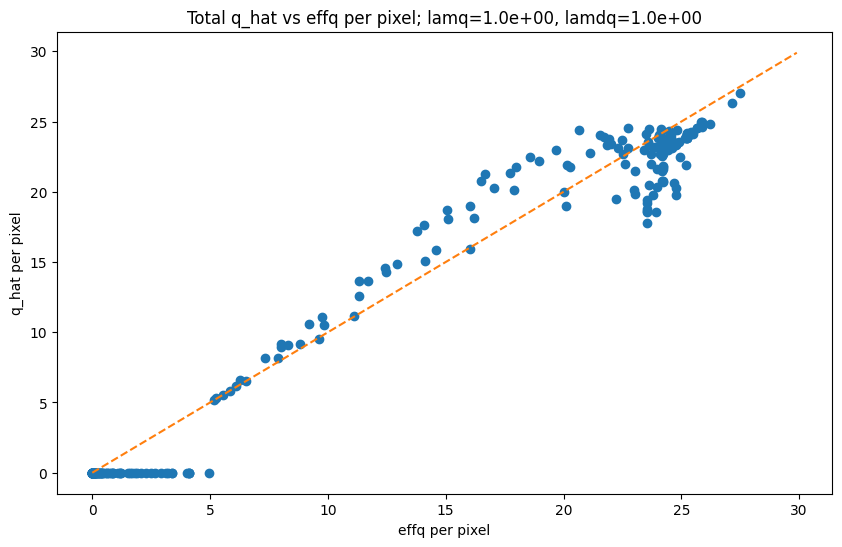

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


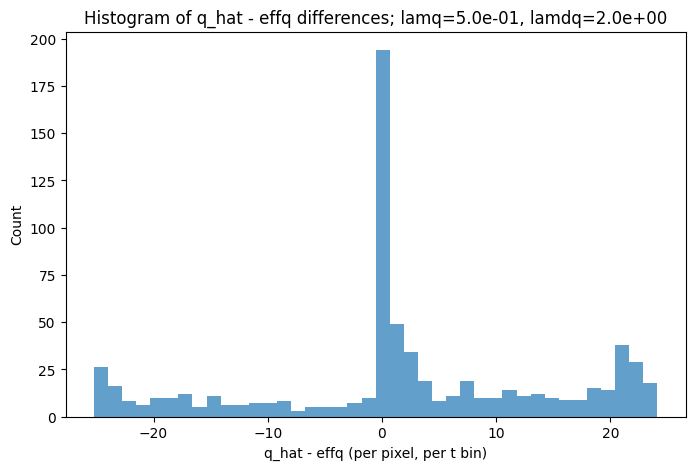

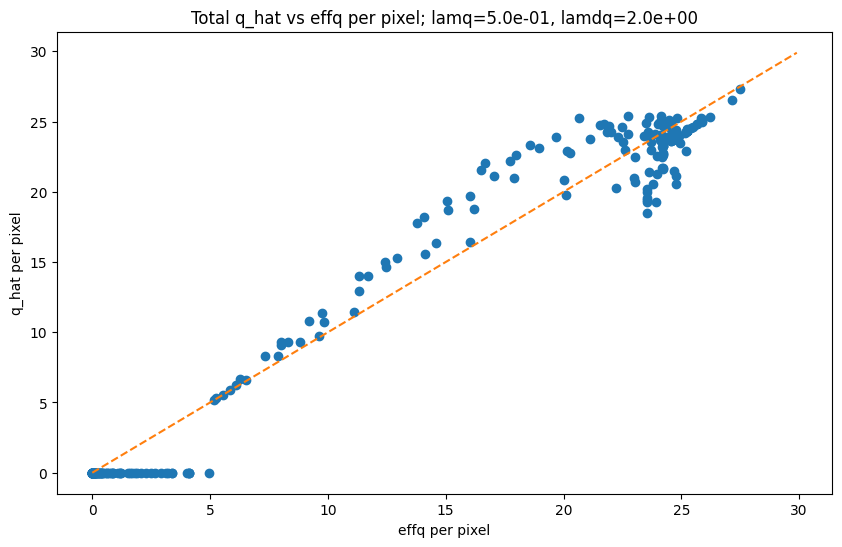

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


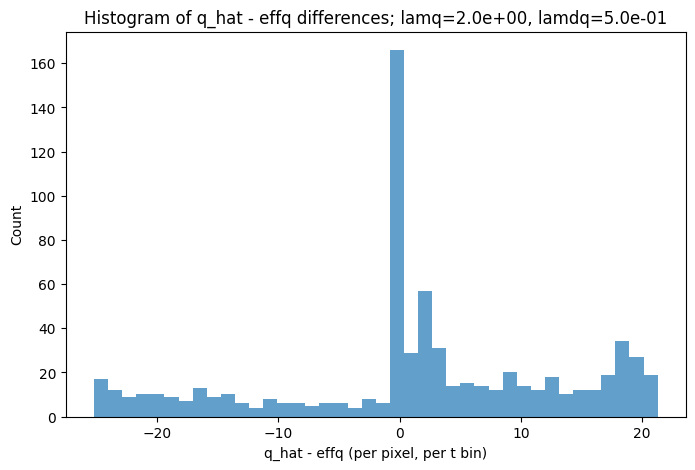

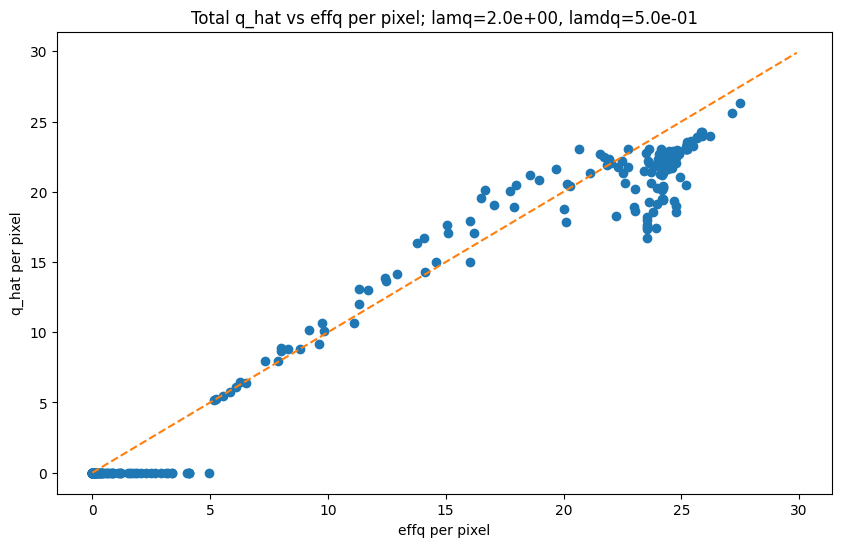

In [10]:
# Try different combinations
study_lam_combo(3, 0)
study_lam_combo(0, 3)
study_lam_combo(1, 1)
study_lam_combo(0.5, 2)
study_lam_combo(2, 0.5)

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


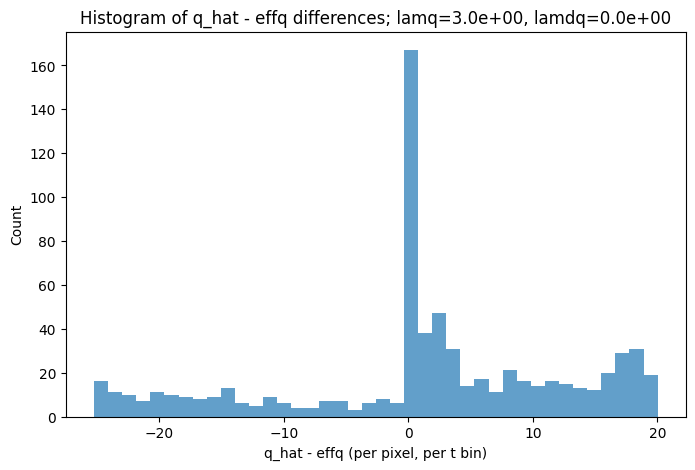

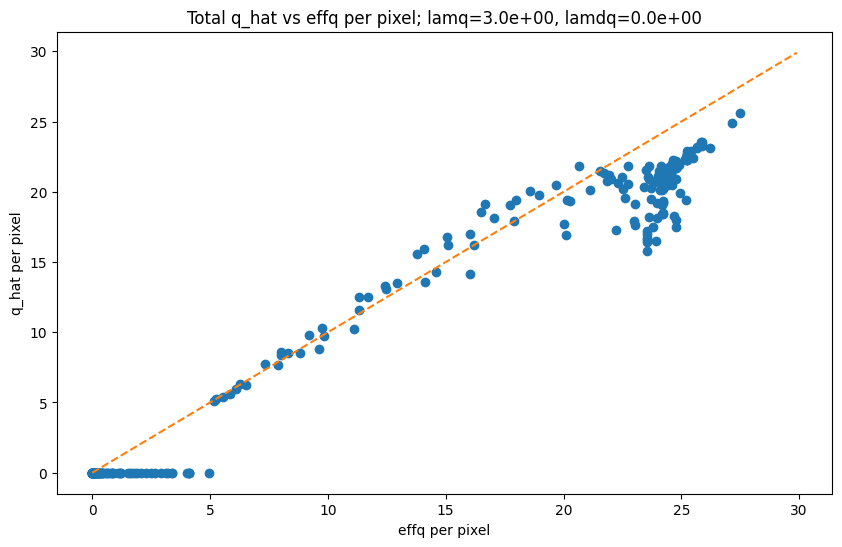

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


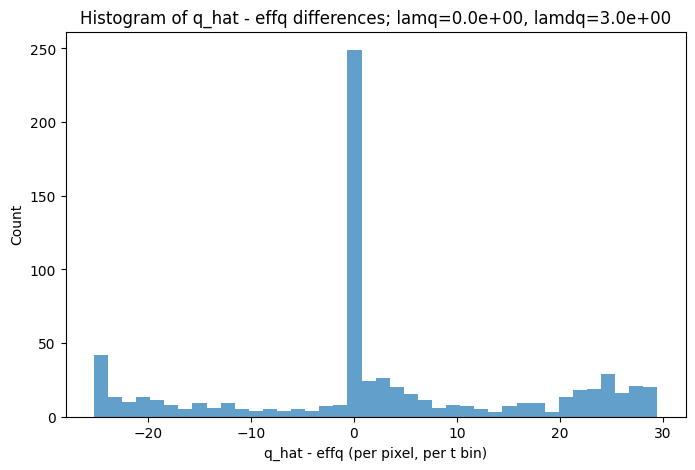

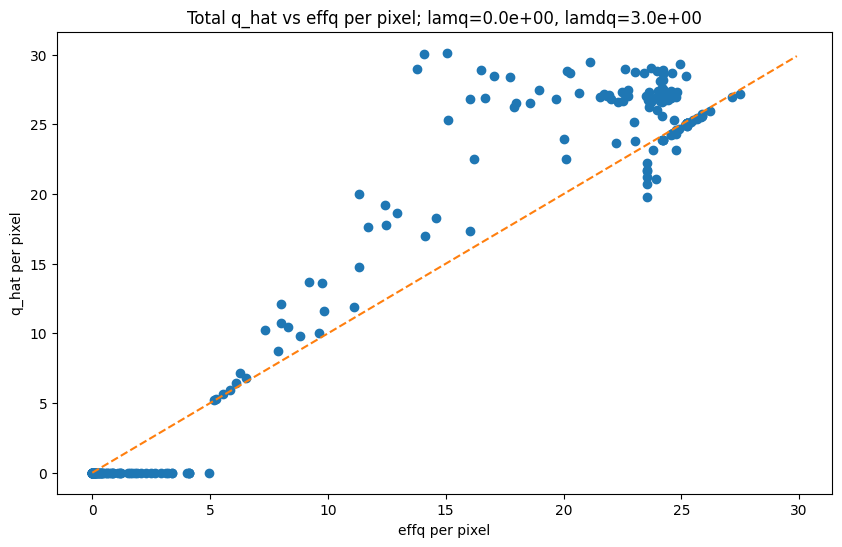

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


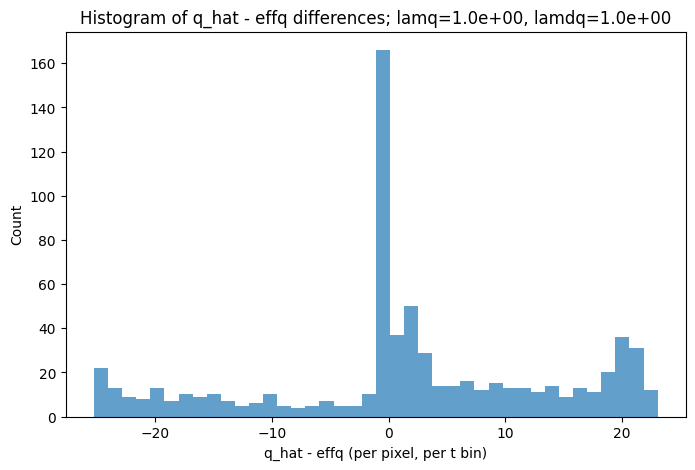

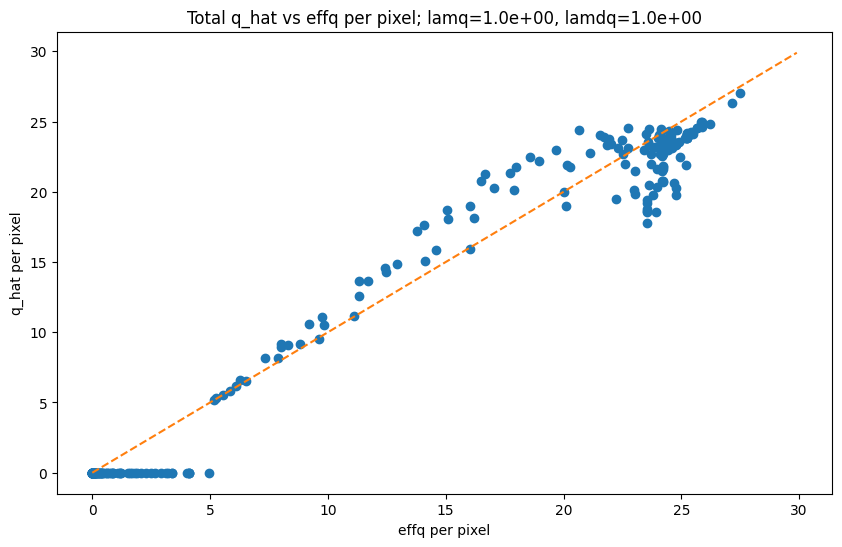

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


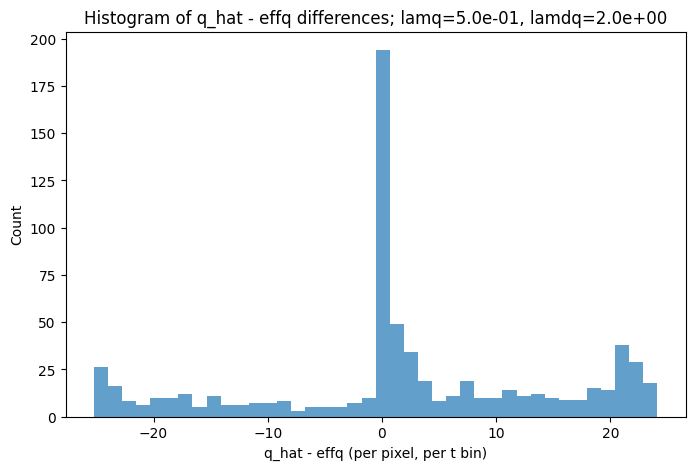

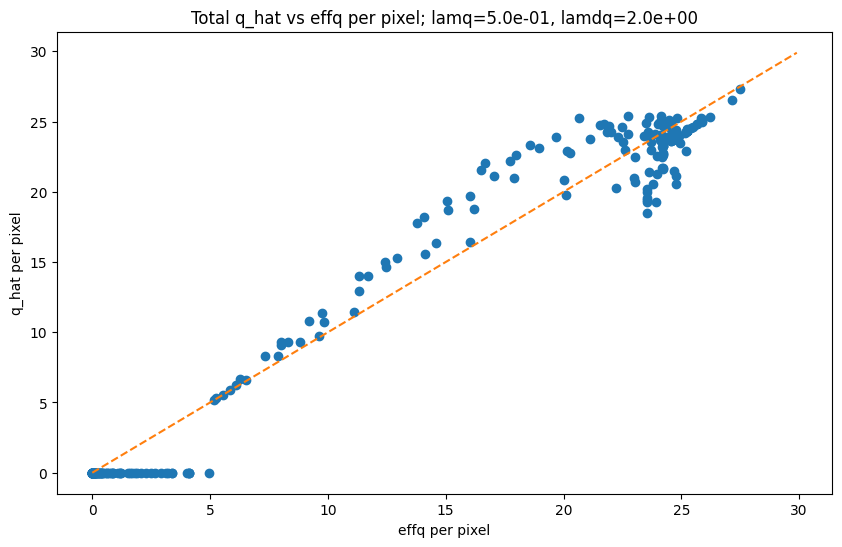

Loaded: 207 hits; unique (px, py) groups = 162
Kernel: len(fr)=1400, sum(fr)=0.996752


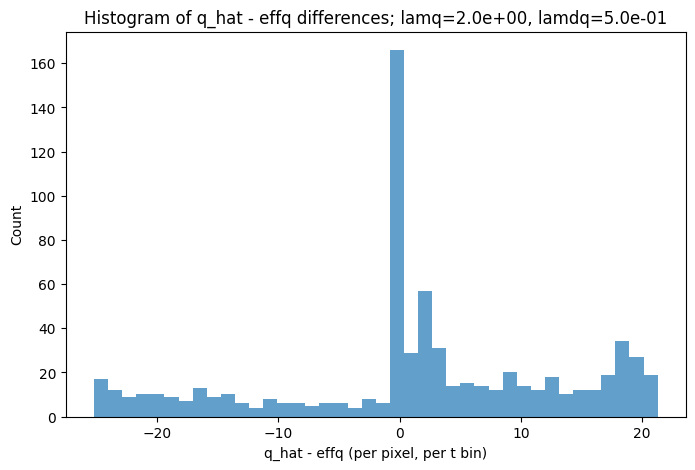

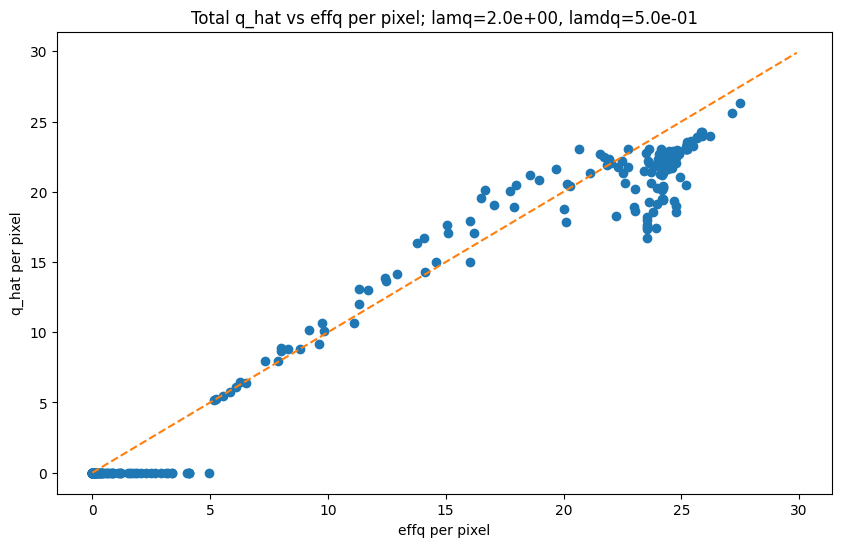

In [13]:
# Try different combinations
study_lam_combo(3, 0, 100, 0, 0)
study_lam_combo(0, 3, 100, 0, 0)
study_lam_combo(1, 1, 100, 0, 0)
study_lam_combo(0.5, 2, 100, 0, 0)
study_lam_combo(2, 0.5, 100, 0, 0)